# Exploratory Data Analysis -- Student Score Prediction
**U.A Secondary School | Adapted from AIAP Technical Assessment**

This notebook performs a structured EDA on the student dataset. Each step is designed to directly inform decisions in the Machine Learning Pipeline (Task 2). The target variable is `final_test` -- a student's O-level mathematics examination score.

---
## Table of Contents
1. [Setup & Data Loading](#1-setup--data-loading)
2. [Target Variable Analysis](#2-target-variable-analysis)
3. [Dataset Overview & Data Quality](#3-dataset-overview--data-quality)
4. [Feature Type Audit](#4-feature-type-audit)
5. [Cardinality & Class Balance of Categoricals](#5-cardinality--class-balance-of-categoricals)
6. [Feature Engineering Candidates](#6-feature-engineering-candidates)
7. [Univariate Analysis of Numerical Features](#7-univariate-analysis-of-numerical-features)
8. [Bivariate Analysis vs. Target](#8-bivariate-analysis-vs-target)
9. [Multicollinearity Check](#9-multicollinearity-check)
10. [Outlier Analysis](#10-outlier-analysis)
11. [Score Segmentation & Business Context](#11-score-segmentation--business-context)
12. [EDA Summary & Pipeline Decisions](#12-eda-summary--pipeline-decisions)


---
## 1. Setup & Data Loading

**Purpose:** Load the dataset from the SQLite database and perform an initial inspection.
The data lives at `data/score.db` and must be accessed via SQL -- no direct CSV imports.


In [93]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)


In [94]:
# Connect and inspect available tables
DB_PATH = "/content/score.db"
conn = sqlite3.connect(DB_PATH)

tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print("Tables in database:")
print(tables)


Tables in database:
    name
0  score


In [95]:
# Load main table (update TABLE_NAME if needed based on output above)
TABLE_NAME = tables['name'][0]
df = pd.read_sql(f"SELECT * FROM {TABLE_NAME};", conn)
conn.close()

print(f"Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()


Dataset loaded: 15900 rows x 18 columns


,index,number_of_siblings,direct_admission,CCA,learning_style,student_id,gender,tuition,final_test,n_male,n_female,age,hours_per_week,attendance_rate,sleep_time,wake_time,mode_of_transport,bag_color
0,0,0,Yes,Sports,Visual,ACN2BE,Female,No,69.00,14.00,2.00,16.00,10.00,91.00,22:00,6:00,private transport,yellow
1,1,2,No,Sports,Auditory,FGXIIZ,Female,No,47.00,4.00,19.00,16.00,7.00,94.00,22:30,6:30,private transport,green
2,2,0,Yes,None,Visual,B9AI9F,Male,No,85.00,14.00,2.00,15.00,8.00,92.00,22:30,6:30,private transport,white
3,3,1,No,Clubs,Auditory,FEVM1T,Female,Yes,64.00,2.00,20.00,15.00,18.00,NaN,21:00,5:00,public transport,yellow
4,4,0,No,Sports,Auditory,AXZN2E,Male,No,66.00,24.00,3.00,16.00,7.00,95.00,21:30,5:30,public transport,yellow


In [96]:
df

,index,number_of_siblings,direct_admission,CCA,learning_style,student_id,gender,tuition,final_test,n_male,n_female,age,hours_per_week,attendance_rate,sleep_time,wake_time,mode_of_transport,bag_color
0,0,0,Yes,Sports,Visual,ACN2BE,Female,No,69.00,14.00,2.00,16.00,10.00,91.00,22:00,6:00,private transport,yellow
1,1,2,No,Sports,Auditory,FGXIIZ,Female,No,47.00,4.00,19.00,16.00,7.00,94.00,22:30,6:30,private transport,green
2,2,0,Yes,None,Visual,B9AI9F,Male,No,85.00,14.00,2.00,15.00,8.00,92.00,22:30,6:30,private transport,white
3,3,1,No,Clubs,Auditory,FEVM1T,Female,Yes,64.00,2.00,20.00,15.00,18.00,NaN,21:00,5:00,public transport,yellow
4,4,0,No,Sports,Auditory,AXZN2E,Male,No,66.00,24.00,3.00,16.00,7.00,95.00,21:30,5:30,public transport,yellow
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15895,15895,1,No,Clubs,Visual,XPECN2,Female,No,56.00,12.00,14.00,16.00,9.00,96.00,22:00,6:00,private transport,black
15896,15896,1,Yes,None,Auditory,7AMC7S,Male,Yes,85.00,17.00,5.00,16.00,7.00,91.00,22:30,6:30,private transport,white
15897,15897,1,Yes,Sports,Auditory,XKZ6VN,Female,Yes,76.00,7.00,10.00,15.00,7.00,93.00,23:00,7:00,walk,red
15898,15898,1,No,Clubs,Visual,2OU4UQ,Male,Yes,45.00,18.00,12.00,16.00,3.00,94.00,23:00,7:00,walk,yellow


---
## 2. Target Variable Analysis

**Purpose:** Understand the distribution of `final_test` -- the score we are predicting.
This determines whether a target transformation is needed and informs evaluation metric choice.

**Key questions:**
- Is the distribution normal, skewed, or bimodal?
- Are there score boundaries that suggest a capped scale (e.g., 0-100)?
- Are there extreme outliers?


In [97]:
target = 'final_test'

print("=== Target Variable Summary ===")
print(df[target].describe())
print(f"\nMedian   : {df[target].median()}")
print(f"\nSkewness : {df[target].skew():.3f}")
print(f"Kurtosis : {df[target].kurt():.3f}")
print(f"Missing  : {df[target].isnull().sum()}")

=== Target Variable Summary ===
count   15405.00
mean       67.17
std        13.98
min        32.00
25%        56.00
50%        68.00
75%        78.00
max       100.00
Name: final_test, dtype: float64

Median   : 68.0

Skewness : 0.056
Kurtosis : -0.729
Missing  : 495


In [98]:
missing_target = df['final_test'].isnull()
print(f"Missing target rows : {missing_target.sum()}")
print(f"Missing target %    : {missing_target.mean() * 100:.2f}%")

# Check if missing rows differ systematically from complete rows
print("\nFeature means -- rows WITH vs WITHOUT target:")
print(df.groupby(missing_target)[['age', 'hours_per_week', 'attendance_rate']].mean())


Missing target rows : 495
Missing target %    : 3.11%

Feature means -- rows WITH vs WITHOUT target:
             age  hours_per_week  attendance_rate
final_test                                       
False      15.21           10.31            93.27
True       15.19           10.32            93.41


Missingness is random since the mean of missing target and non-missing targets are similar. I will drop the rows with missing target, since imputation without GT will taint my ML solution.

In [99]:
df = df.dropna(subset=['final_test']).reset_index(drop=True)
missing_target = df['final_test'].isnull()
print(f"Missing target rows after dropping : {missing_target.sum()}")

Missing target rows after dropping : 0


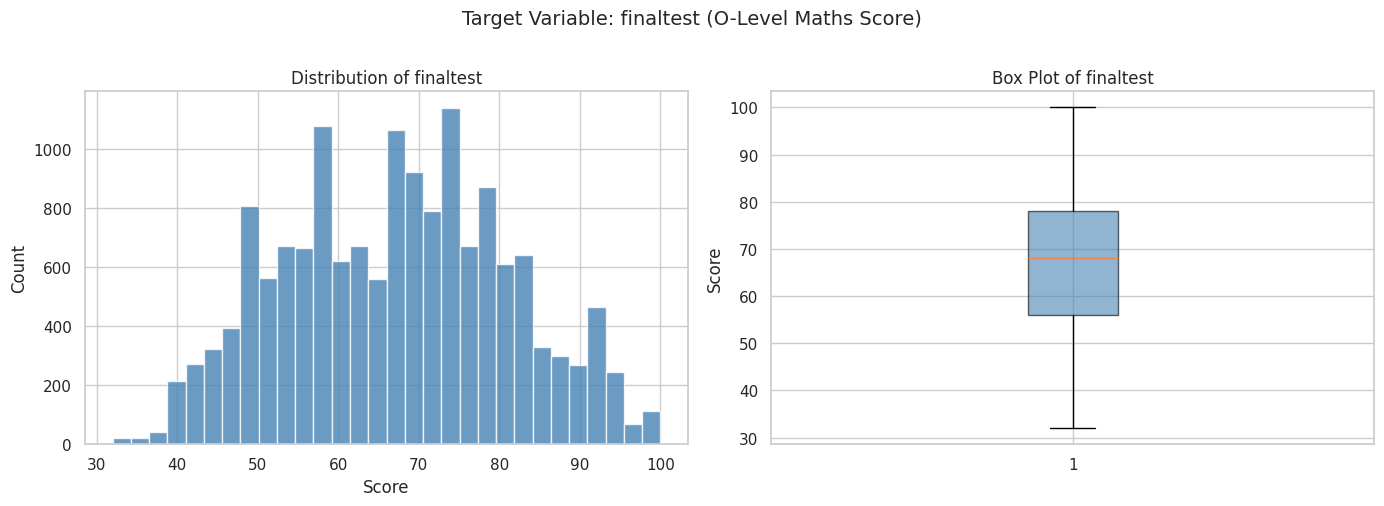


PIPELINE DECISION:
  - If |skewness| > 0.5  => consider log/sqrt transform on target
  - Confirm actual min/max to understand scoring scale
  - Outlier treatment strategy defined in Step 10



In [100]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[target].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution of finaltest')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Count')

axes[1].boxplot(df[target].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Box Plot of finaltest')
axes[1].set_ylabel('Score')

plt.suptitle('Target Variable: finaltest (O-Level Maths Score)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("""
PIPELINE DECISION:
  - If |skewness| > 0.5  => consider log/sqrt transform on target
  - Confirm actual min/max to understand scoring scale
  - Outlier treatment strategy defined in Step 10
""")


---
## 3. Dataset Overview & Data Quality

**Purpose:** Identify data quality issues -- missing values, duplicates, and incorrect data types.
These findings determine the imputation and cleaning logic in the pipeline's preprocessing step.


In [101]:
print("=== Shape ===")
print(df.shape)

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Duplicate Rows ===")
print(f"Total duplicates    : {df.duplicated().sum()}")
print(f"Duplicate student_ids: {df['student_id'].duplicated().sum()}")


=== Shape ===
(15405, 18)

=== Data Types ===
index                   int64
number_of_siblings      int64
direct_admission       object
CCA                    object
learning_style         object
student_id             object
gender                 object
tuition                object
final_test            float64
n_male                float64
n_female              float64
age                   float64
hours_per_week        float64
attendance_rate       float64
sleep_time             object
wake_time              object
mode_of_transport      object
bag_color              object
dtype: object

=== Duplicate Rows ===
Total duplicates    : 0
Duplicate student_ids: 846


In [102]:
# Quick check: is the index column just row numbers?
print(df['index'].is_monotonic_increasing)      # True = likely auto-generated
print(df['index'].nunique() == df.shape[0])     # True = unique, but is it meaningful?
print(df[['index', 'student_id']].head(20))      # Visually confirm relationship

True
True
    index student_id
0       0     ACN2BE
1       1     FGXIIZ
2       2     B9AI9F
3       3     FEVM1T
4       4     AXZN2E
5       5     BA6R14
6       6     D5WGTI
7       7     HTP8CW
8       8     U3YRTC
9       9     3MOMA6
10     10     5KDLKU
11     11     PUMBWU
12     12     T4U89N
13     13     WPWT99
14     14     G0JBVS
15     15     VRSYQL
16     16     W087TC
17     17     FALLVI
18     18     H014YN
19     19     ZQ3KFP


In [103]:
df = df.drop(columns=['index'])
# dropping index since it appears to be an auto-generated identifier with no meaningful relationship to student_id or target variable.

In [104]:
# Separate true duplicates from conflicting duplicates
dupes = df[df['student_id'].duplicated(keep=False)].sort_values('student_id')

# True duplicates: entire row is identical
true_dupes = df[df.duplicated(keep=False)]

# Conflicting duplicates: same student_id, but different values in other columns
conflicting_dupes = dupes[~dupes.duplicated(keep=False)]

print(f"Total rows with duplicate student_id : {len(dupes)}")
print(f"True full-row duplicates            : {len(true_dupes)}")
print(f"Conflicting records (same ID, diff) : {len(conflicting_dupes)}")

# Inspect conflicting cases
conflicting_dupes.head(20)

Total rows with duplicate student_id : 1692
True full-row duplicates            : 276
Conflicting records (same ID, diff) : 1416


,number_of_siblings,direct_admission,CCA,learning_style,student_id,gender,tuition,final_test,n_male,n_female,age,hours_per_week,attendance_rate,sleep_time,wake_time,mode_of_transport,bag_color
5356,0,No,Clubs,Auditory,00811H,Female,Yes,88.00,21.00,4.00,15.00,8.00,92.00,23:00,7:00,walk,green
11915,0,No,Clubs,Auditory,00811H,Female,Yes,88.00,21.00,4.00,15.00,8.00,92.00,23:00,7:00,walk,white
4166,0,No,Clubs,Auditory,02RSAH,Female,Yes,64.00,12.00,9.00,15.00,17.00,97.00,22:00,6:00,private transport,yellow
8900,0,No,Clubs,Auditory,02RSAH,Female,Yes,64.00,12.00,9.00,15.00,17.00,97.00,22:00,6:00,private transport,green
8388,0,No,Arts,Auditory,0FC4RY,Female,No,68.00,23.00,4.00,15.00,6.00,NaN,23:00,7:00,walk,blue
9497,0,No,Arts,Auditory,0FC4RY,Female,No,68.00,23.00,4.00,15.00,6.00,100.00,23:00,7:00,walk,yellow
6145,0,Yes,None,Visual,0JUGAF,Female,No,84.00,18.00,2.00,16.00,10.00,94.00,23:00,7:00,walk,yellow
1376,0,Yes,None,Visual,0JUGAF,Female,No,84.00,18.00,2.00,16.00,10.00,94.00,23:00,7:00,walk,red
15231,0,Yes,None,Auditory,0K5LDV,Female,Yes,84.00,9.00,12.00,16.00,9.00,98.00,22:00,6:00,private transport,red
8884,0,Yes,None,Auditory,0K5LDV,Female,Yes,84.00,9.00,12.00,16.00,9.00,98.00,22:00,6:00,private transport,white


We will drop the duplicates from the 276 rows (these are exact duplicates).

In [105]:
df = df.drop_duplicates().reset_index(drop=True)

We will now examine the rest of the non-exact duplicates.

In [106]:
# Examine what differs between records for the same student
cols_to_check = [c for c in df.columns if c != 'student_id']

for col in cols_to_check:
    n_conflict = conflicting_dupes.groupby('student_id')[col].nunique()
    n_with_conflict = (n_conflict > 1).sum()
    if n_with_conflict > 0:
        print(f"{col:20s} -> {n_with_conflict} students have conflicting values")


bag_color            -> 685 students have conflicting values


Looks like all the non-exact duplicates are in the column bag_color. This is not a useful column for our task of predicting exam scores. Removing them.

=== Missing Values ===
                 Missing Count  Missing %
attendance_rate            757       4.96


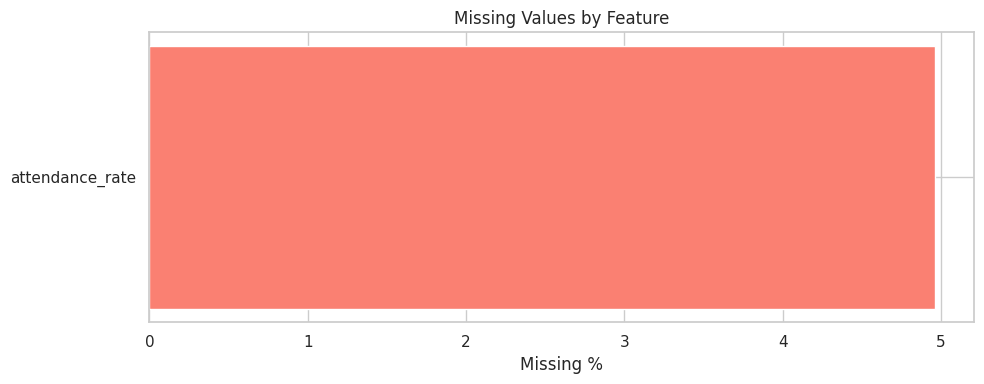

In [107]:
# Missing value summary
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df  = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df  = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print("=== Missing Values ===")
if missing_df.empty:
    print("No missing values found.")
else:
    print(missing_df)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(missing_df.index, missing_df['Missing %'], color='salmon')
    ax.set_xlabel('Missing %')
    ax.set_title('Missing Values by Feature')
    plt.tight_layout()
    plt.show()


We will now diagnose the missing values to see if they are random or systematic. Random would mean that missing rows have similar final_test to the no missing, and that it is safe to use median imputation. If the rows with missing attendnace_rate have notably higher or lower final_test score, it would mean systematic misssingness, which may require group-wise miedian or flag missingness.

In [108]:
missing_mask = df['attendance_rate'].isnull()

present = df.loc[~missing_mask, 'final_test']
missing = df.loc[missing_mask, 'final_test']

print("=== final_test where attendance_rate is PRESENT ===")
print(present.describe())

print("\n=== final_test where attendance_rate is MISSING ===")
print(missing.describe())

print(f"\nMean difference: {abs(present.mean() - missing.mean()):.2f} points")

df['attendance_missing'] = df['attendance_rate'].isnull()

print("=== finaltest: missing vs present attendance_rate ===")
print(df.groupby('attendance_missing')['final_test'].describe())

# Are missing rows concentrated in any category?
for col in ['gender', 'tuition', 'CCA', 'learningstyle']:
    if col in df.columns:
        print(f"\n--- {col} ---")
        print(df.groupby(col)['attendance_missing'].mean().round(3))

=== final_test where attendance_rate is PRESENT ===
count   14510.00
mean       67.15
std        13.97
min        32.00
25%        56.00
50%        68.00
75%        78.00
max       100.00
Name: final_test, dtype: float64

=== final_test where attendance_rate is MISSING ===
count   757.00
mean     67.54
std      14.28
min      32.00
25%      57.00
50%      69.00
75%      79.00
max     100.00
Name: final_test, dtype: float64

Mean difference: 0.38 points
=== finaltest: missing vs present attendance_rate ===
                      count  mean   std   min   25%   50%   75%    max
attendance_missing                                                    
False              14510.00 67.15 13.97 32.00 56.00 68.00 78.00 100.00
True                 757.00 67.54 14.28 32.00 57.00 69.00 79.00 100.00

--- gender ---
gender
Female   0.05
Male     0.05
Name: attendance_missing, dtype: float64

--- tuition ---
tuition
N     0.05
No    0.05
Y     0.04
Yes   0.05
Name: attendance_missing, dtype: float64

--

The distribution of the missing values appear to be random, we will use global median to impute. Prefer median over mean to avoid any low attendence skew.

---
## 4. Feature Type Audit

**Purpose:** Classify every feature into its processing category.
This is the foundation for the `ColumnTransformer` in the pipeline -- each group is routed to the appropriate transformer.


In [109]:
feature_audit = {
    'studentid'        : 'ID -- Drop',
    'numberofsiblings' : 'Numerical (discrete)',
    'directadmission'  : 'Categorical (nominal)',
    'CCA'              : 'Categorical (nominal)',
    'learningstyle'    : 'Categorical (nominal)',
    'tuition'          : 'Categorical (binary)',
    'nmale'            : 'Numerical (discrete) -- Engineer',
    'nfemale'          : 'Numerical (discrete) -- Engineer',
    'gender'           : 'Categorical (binary)',
    'age'              : 'Numerical (continuous)',
    'hoursperweek'     : 'Numerical (continuous)',
    'attendancerate'   : 'Numerical (continuous)',
    'sleeptime'        : 'Time String -- Engineer to sleep_duration',
    'waketime'         : 'Time String -- Engineer to sleep_duration',
    'modeoftransport'  : 'Categorical (nominal)',
    'bagcolor'         : 'Categorical (nominal) -- Low Signal?',
    'finaltest'        : 'TARGET',
}

audit_df = pd.DataFrame(list(feature_audit.items()), columns=['Feature', 'Type'])
print(audit_df.to_string(index=False))


         Feature                                      Type
       studentid                                ID -- Drop
numberofsiblings                      Numerical (discrete)
 directadmission                     Categorical (nominal)
             CCA                     Categorical (nominal)
   learningstyle                     Categorical (nominal)
         tuition                      Categorical (binary)
           nmale          Numerical (discrete) -- Engineer
         nfemale          Numerical (discrete) -- Engineer
          gender                      Categorical (binary)
             age                    Numerical (continuous)
    hoursperweek                    Numerical (continuous)
  attendancerate                    Numerical (continuous)
       sleeptime Time String -- Engineer to sleep_duration
        waketime Time String -- Engineer to sleep_duration
 modeoftransport                     Categorical (nominal)
        bagcolor      Categorical (nominal) -- Low Signa

In [110]:
print("\n=== Actual Unique Value Counts per Feature ===")
print(df.nunique().sort_values())



=== Actual Unique Value Counts per Feature ===
direct_admission          2
learning_style            2
gender                    2
attendance_missing        2
mode_of_transport         3
number_of_siblings        3
tuition                   4
wake_time                 5
bag_color                 6
age                       6
CCA                       8
sleep_time               13
hours_per_week           21
n_female                 32
n_male                   32
attendance_rate          61
final_test               68
student_id            14559
dtype: int64


The entry for some fields appear to be different even when they intended to mean the same thing. Eg CCA type capitalisation and Yes No Y N. We will standardise these.

In [111]:
tuition_map = {'Yes': 1, 'Y': 1, 'No': 0, 'N': 0}
df['tuition'] = df['tuition'].map(tuition_map)

# Verify
print(df['tuition'].value_counts())

tuition
1    8649
0    6618
Name: count, dtype: int64


In [112]:
df['CCA'] = df['CCA'].str.capitalize()

# Verify — should only show: Sports, Arts, Clubs, None
print(df['CCA'].value_counts())


CCA
Clubs     3905
Sports    3807
None      3795
Arts      3760
Name: count, dtype: int64


Mean : 72.40
Median: 76.00
Std  : 14.03


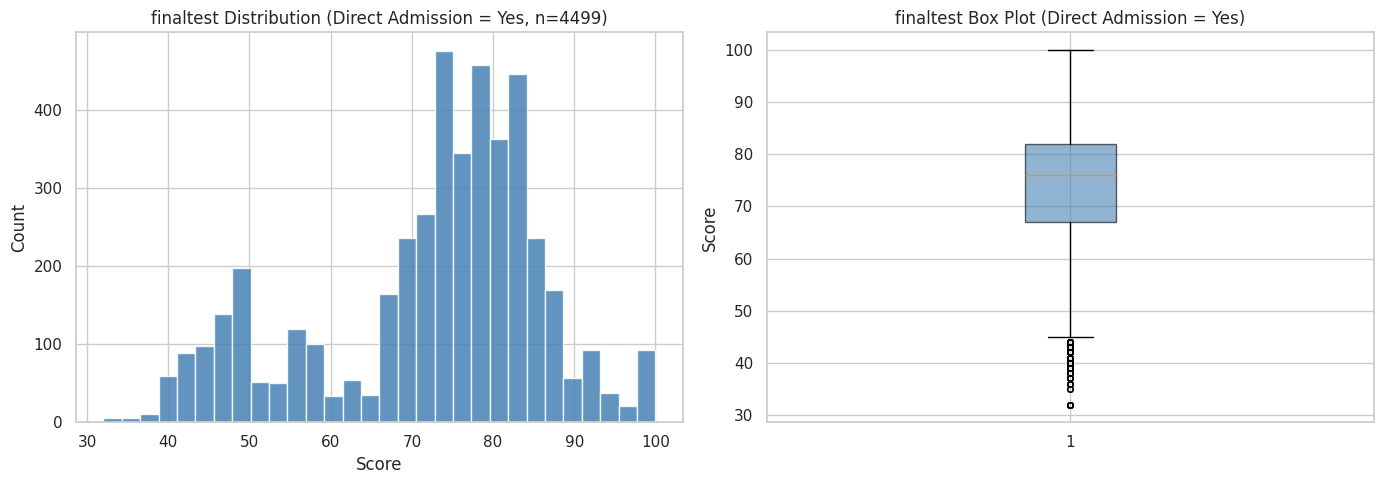

In [113]:
subset = df[df['direct_admission'] == 'Yes']['final_test'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(subset, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title(f'finaltest Distribution (Direct Admission = Yes, n={len(subset)})')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Count')

axes[1].boxplot(subset, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                flierprops=dict(marker='o', color='red', markersize=4))
axes[1].set_title('finaltest Box Plot (Direct Admission = Yes)')
axes[1].set_ylabel('Score')

print(f"Mean : {subset.mean():.2f}")
print(f"Median: {subset.median():.2f}")
print(f"Std  : {subset.std():.2f}")

plt.tight_layout()
plt.show()


---
## 5. Cardinality & Class Balance of Categoricals

**Purpose:** Understand the spread of categorical features.
High cardinality may require target encoding; rare categories may need grouping before one-hot encoding.


In [114]:
categorical_cols = ['directadmission', 'CCA', 'learningstyle', 'tuition',
                    'gender', 'modeoftransport', 'bagcolor']
categorical_cols = [c for c in categorical_cols if c in df.columns]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    vc  = df[col].value_counts(dropna=False)
    pct = (vc / len(df) * 100).round(1)
    print(pd.concat([vc, pct.rename('%')], axis=1).to_string())



--- CCA ---
        count     %
CCA                
Clubs    3905 25.60
Sports   3807 24.90
None     3795 24.90
Arts     3760 24.60

--- tuition ---
         count     %
tuition             
1         8649 56.70
0         6618 43.30

--- gender ---
        count     %
gender             
Male     7684 50.30
Female   7583 49.70


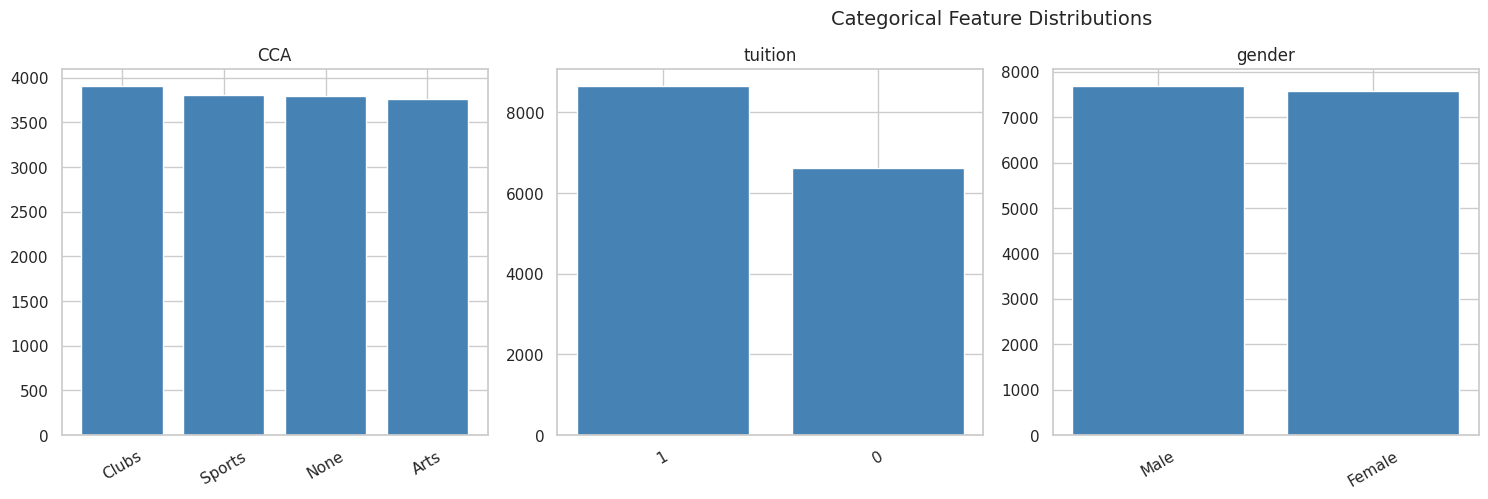


PIPELINE DECISION:
  - Low cardinality (<=5 unique) => OneHotEncoder
  - High cardinality or rare classes => group rare categories as 'Other', then OHE
  - bagcolor: inspect correlation with target in Step 8 before deciding to keep or drop



In [115]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    vc = df[col].value_counts(dropna=False)
    axes[i].bar(vc.index.astype(str), vc.values, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=30)

for j in range(len(categorical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

print("""
PIPELINE DECISION:
  - Low cardinality (<=5 unique) => OneHotEncoder
  - High cardinality or rare classes => group rare categories as 'Other', then OHE
  - bagcolor: inspect correlation with target in Step 8 before deciding to keep or drop
""")


---
## 6. Feature Engineering Candidates

**Purpose:** Extract latent information from raw features that are not directly usable.
All transformations identified here must be reproduced as reusable transformer classes in `src/`.

| Raw Feature(s)       | Engineered Feature        | Rationale |
|----------------------|---------------------------|-----------|
| `sleeptime`, `waketime` | `sleep_duration` (hours) | Duration of sleep affects rest and cognitive performance |
| `nmale`, `nfemale`   | `class_size`, `male_ratio` | Class composition may affect the learning environment |
| `numberofsiblings`   | Optional: bin 0 / 1 / 2+  | Diminishing effect beyond 2 siblings |


In [116]:
def parse_time_to_minutes(t):
    """Convert 'HH:MM' string to total minutes since midnight."""
    try:
        parts = str(t).strip().split(':')
        return int(parts[0]) * 60 + int(parts[1])
    except Exception:
        return np.nan

if 'sleep_time' in df.columns and 'wake_time' in df.columns:
    df['sleep_min'] = df['sleep_time'].apply(parse_time_to_minutes)
    df['wake_min']  = df['wake_time'].apply(parse_time_to_minutes)
    # Handle overnight sleep (e.g., sleep 23:00, wake 07:00)
    df['sleep_duration'] = df.apply(
        lambda r: (r['wake_min'] - r['sleep_min']) % (24 * 60) / 60, axis=1
    )
    print("sleep_duration (hours) -- Sample:")
    print(df[['sleep_time', 'wake_time', 'sleep_duration']].head(10))
    print(f"\nStats:\n{df['sleep_duration'].describe()}")


sleep_duration (hours) -- Sample:
  sleep_time wake_time  sleep_duration
0      22:00      6:00            8.00
1      22:30      6:30            8.00
2      22:30      6:30            8.00
3      21:00      5:00            8.00
4      21:30      5:30            8.00
5      22:30      6:30            8.00
6      21:30      5:30            8.00
7      21:00      5:00            8.00
8      22:00      6:00            8.00
9      22:30      6:30            8.00

Stats:
count   15267.00
mean        7.85
std         0.60
min         4.00
25%         8.00
50%         8.00
75%         8.00
max         8.00
Name: sleep_duration, dtype: float64


In [117]:
if 'n_male' in df.columns and 'n_female' in df.columns:
    df['class_size'] = df['n_male'] + df['n_female']
    df['male_ratio'] = df['n_male'] / df['class_size'].replace(0, np.nan)
    print("class_size and male_ratio -- Sample:")
    print(df[['n_male', 'n_female', 'class_size', 'male_ratio']].head(10))


class_size and male_ratio -- Sample:
   n_male  n_female  class_size  male_ratio
0   14.00      2.00       16.00        0.88
1    4.00     19.00       23.00        0.17
2   14.00      2.00       16.00        0.88
3    2.00     20.00       22.00        0.09
4   24.00      3.00       27.00        0.89
5    9.00     12.00       21.00        0.43
6   12.00      3.00       15.00        0.80
7   20.00      2.00       22.00        0.91
8   20.00      7.00       27.00        0.74
9   13.00      9.00       22.00        0.59


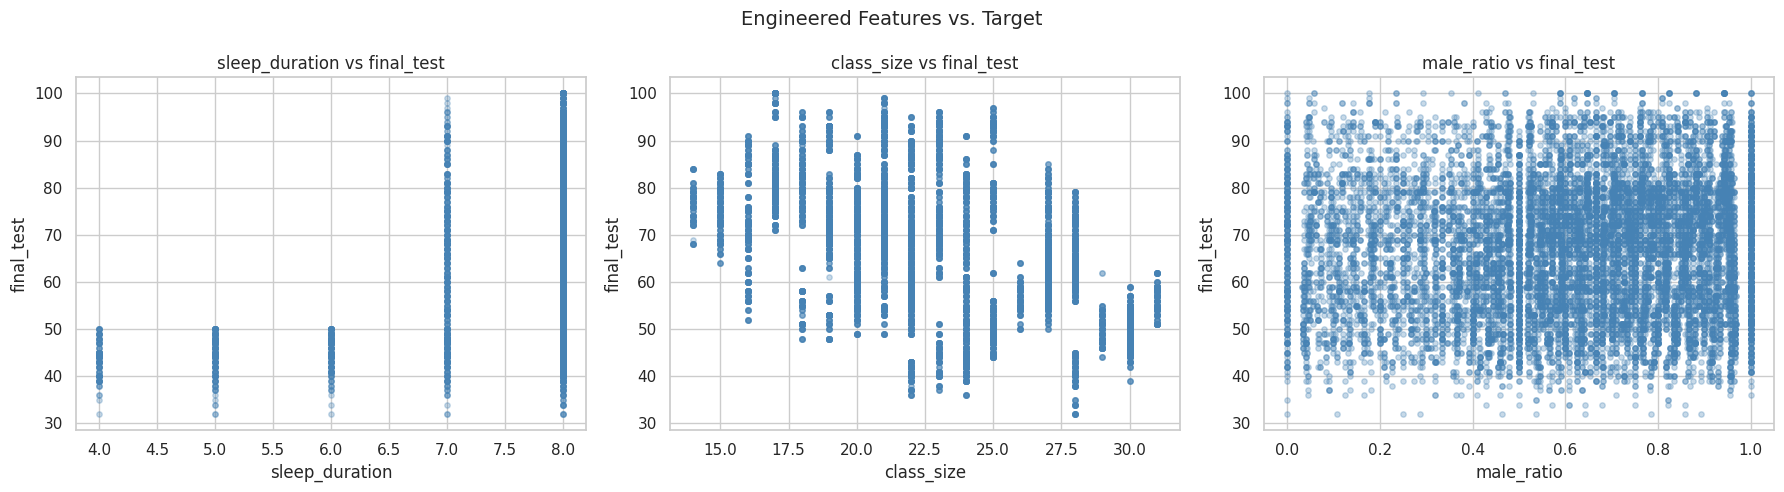


PIPELINE DECISION:
  - Add TimeFeatureEngineer transformer (src/) that computes sleep_duration
  - Add ClassFeatureEngineer for class_size and male_ratio
  - Drop raw sleeptime, waketime, nmale, nfemale after engineering



In [118]:
eng_feats = [f for f in ['sleep_duration', 'class_size', 'male_ratio'] if f in df.columns]

if eng_feats:
    fig, axes = plt.subplots(1, len(eng_feats), figsize=(6 * len(eng_feats), 5))
    if len(eng_feats) == 1:
        axes = [axes]
    for ax, feat in zip(axes, eng_feats):
        ax.scatter(df[feat], df['final_test'], alpha=0.3, color='steelblue', s=15)
        ax.set_xlabel(feat)
        ax.set_ylabel('final_test')
        ax.set_title(f'{feat} vs final_test')
    plt.suptitle('Engineered Features vs. Target', fontsize=14)
    plt.tight_layout()
    plt.show()

print("""
PIPELINE DECISION:
  - Add TimeFeatureEngineer transformer (src/) that computes sleep_duration
  - Add ClassFeatureEngineer for class_size and male_ratio
  - Drop raw sleeptime, waketime, nmale, nfemale after engineering
""")


---
## 7. Univariate Analysis of Numerical Features

**Purpose:** Assess distribution, spread, and scaling needs for each numerical feature.
Determines whether to use StandardScaler, MinMaxScaler, or RobustScaler in the pipeline.


In [119]:
numerical_cols = ['age', 'hoursperweek', 'attendancerate', 'numberofsiblings',
                  'sleep_duration', 'class_size']
numerical_cols = [c for c in numerical_cols if c in df.columns]

print("=== Descriptive Statistics ===")
print(df[numerical_cols].describe().T)


=== Descriptive Statistics ===
                  count  mean  std   min   25%   50%   75%   max
age            15267.00 15.21 1.76 -5.00 15.00 15.00 16.00 16.00
sleep_duration 15267.00  7.85 0.60  4.00  8.00  8.00  8.00  8.00
class_size     15267.00 22.78 4.23 14.00 20.00 22.00 27.00 31.00


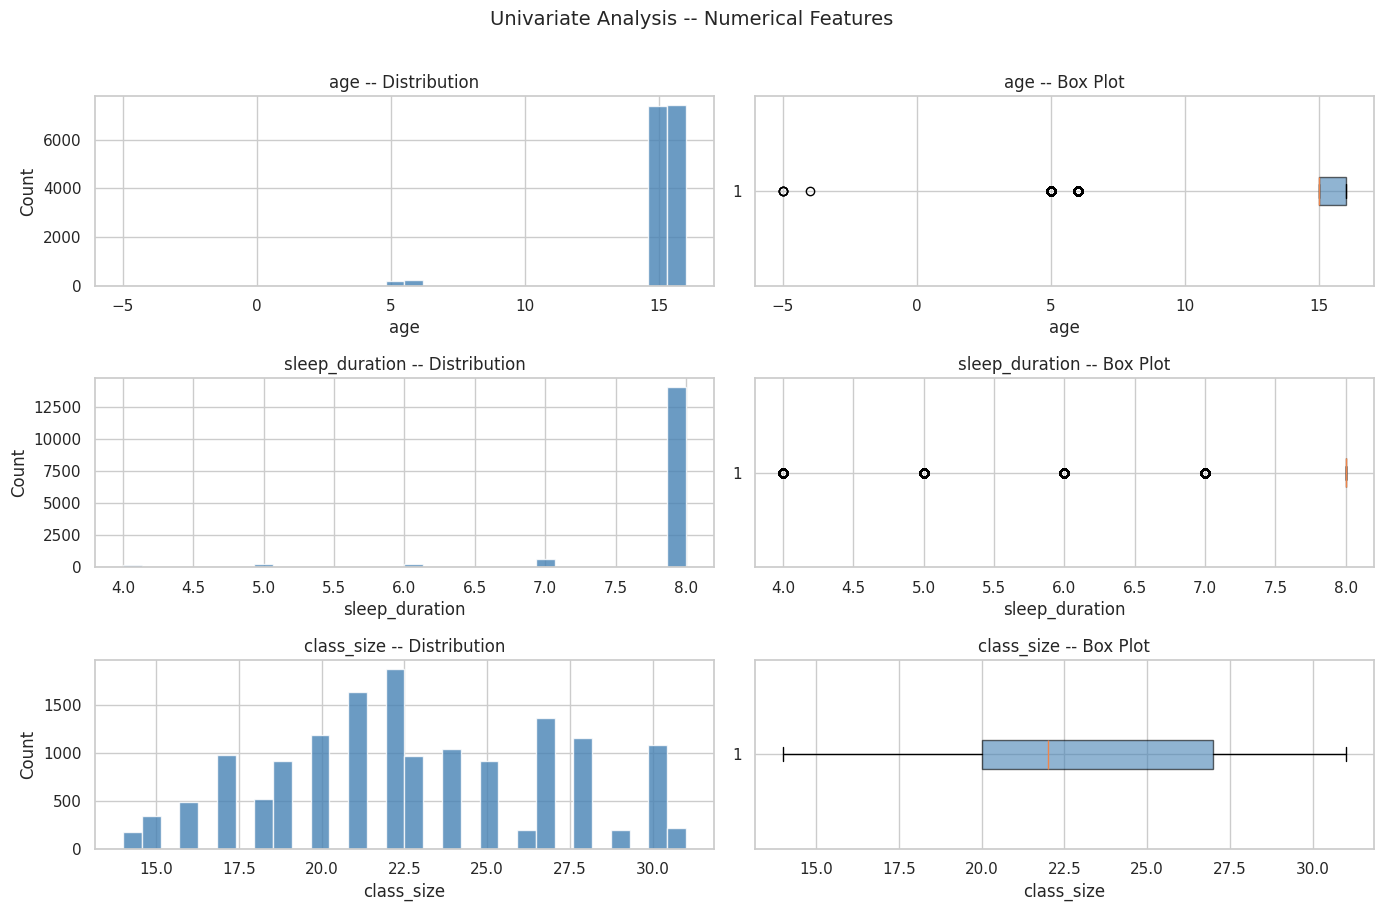

Min   : -5.0
Max   : 16.0
Mean  : 15.21
Unique ages: [-5.0, -4.0, 5.0, 6.0, 15.0, 16.0]


In [120]:
fig, axes = plt.subplots(len(numerical_cols), 2,
                         figsize=(14, len(numerical_cols) * 3),
                         squeeze=False)  # forces axes to always be 2D

for i, col in enumerate(numerical_cols):
    data = df[col].dropna()

    axes[i, 0].hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i, 0].set_title(f'{col} -- Distribution')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Count')

    axes[i, 1].boxplot(data, vert=False, patch_artist=True,
                       boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i, 1].set_title(f'{col} -- Box Plot')
    axes[i, 1].set_xlabel(col)

plt.suptitle('Univariate Analysis -- Numerical Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f"Min   : {age_data.min()}")
print(f"Max   : {age_data.max()}")
print(f"Mean  : {age_data.mean():.2f}")
print(f"Unique ages: {sorted(age_data.unique().tolist())}")


In [121]:
skew_df = df[numerical_cols].skew().reset_index()
skew_df.columns = ['Feature', 'Skewness']
skew_df['Abs Skewness'] = skew_df['Skewness'].abs()
skew_df['Recommendation'] = skew_df['Abs Skewness'].apply(
    lambda s: 'Log/Sqrt Transform' if s > 1 else (
              'Mild Skew -- Monitor' if s > 0.5 else 'Normal -- StandardScaler OK')
)
print(skew_df.sort_values('Abs Skewness', ascending=False).to_string(index=False))

print("""
PIPELINE DECISION:
  - |skew| > 1    => apply np.log1p before scaling
  - Remaining     => StandardScaler (or RobustScaler if outliers are heavy)
""")


       Feature  Skewness  Abs Skewness              Recommendation
           age     -5.16          5.16          Log/Sqrt Transform
sleep_duration     -4.56          4.56          Log/Sqrt Transform
    class_size      0.08          0.08 Normal -- StandardScaler OK

PIPELINE DECISION:
  - |skew| > 1    => apply np.log1p before scaling
  - Remaining     => StandardScaler (or RobustScaler if outliers are heavy)



In [122]:
# How many invalid age rows are there?
invalid_ages = df[~df['age'].isin([15, 16])]
print(f"Rows with invalid age: {len(invalid_ages)}")
print(invalid_ages['age'].value_counts())

# Are their other fields (hoursperweek, finaltest) plausible?
# i.e., do these look like real students with a typo, or garbage rows?
print(invalid_ages[['age', 'final_test', 'hours_per_week', 'attendance_rate']].head(20))


Rows with invalid age: 434
age
6.00     225
5.00     204
-5.00      4
-4.00      1
Name: count, dtype: int64
     age  final_test  hours_per_week  attendance_rate
58  5.00       40.00            5.00            98.00
59  6.00       57.00           11.00            95.00
79  5.00       57.00            6.00            96.00
80  5.00       70.00           10.00            96.00
81  6.00       52.00            8.00            95.00
112 6.00       72.00           10.00            97.00
138 5.00       72.00           10.00            99.00
140 5.00       61.00            7.00            91.00
143 6.00       41.00            8.00            96.00
152 6.00       72.00           12.00            94.00
183 6.00       72.00            5.00            95.00
227 5.00       78.00            9.00            96.00
262 6.00       48.00            5.00            97.00
290 6.00       80.00            9.00            94.00
362 5.00       74.00            8.00              NaN
436 5.00       44.00       

In [123]:
age_fix_map = {5: 15, 6: 16}  # recoverable typos
df['age'] = df['age'].replace(age_fix_map)
df = df[df['age'].isin([15, 16])].reset_index(drop=True)  # drops negative

---
## 8. Bivariate Analysis vs. Target

**Purpose:** Measure the relationship between each feature and `finaltest`.
This justifies which features to keep, which to drop, and influences model selection.


=== Pearson Correlation with final_test ===
class_size       -0.50
age               0.01
sleep_duration    0.33
Name: final_test, dtype: float64


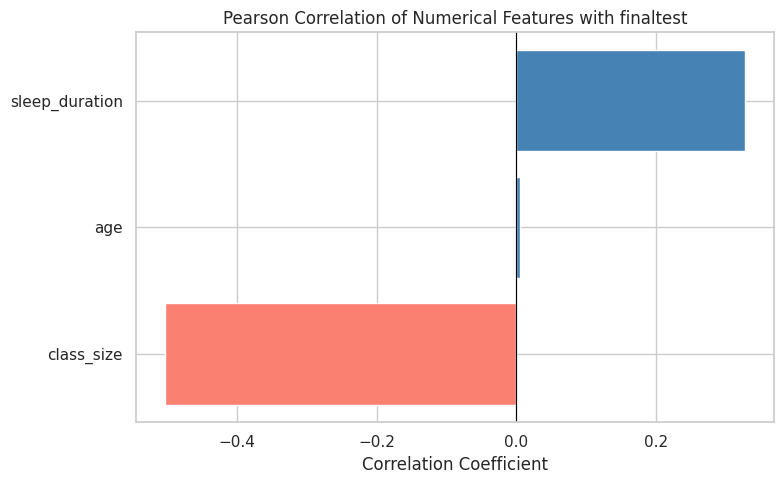

In [124]:
# Pearson correlation -- numerical features
corr_num = df[numerical_cols + ['final_test']].corr()['final_test'].drop('final_test').sort_values()

print("=== Pearson Correlation with final_test ===")
print(corr_num)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['salmon' if v < 0 else 'steelblue' for v in corr_num]
ax.barh(corr_num.index, corr_num.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson Correlation of Numerical Features with finaltest')
ax.set_xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()


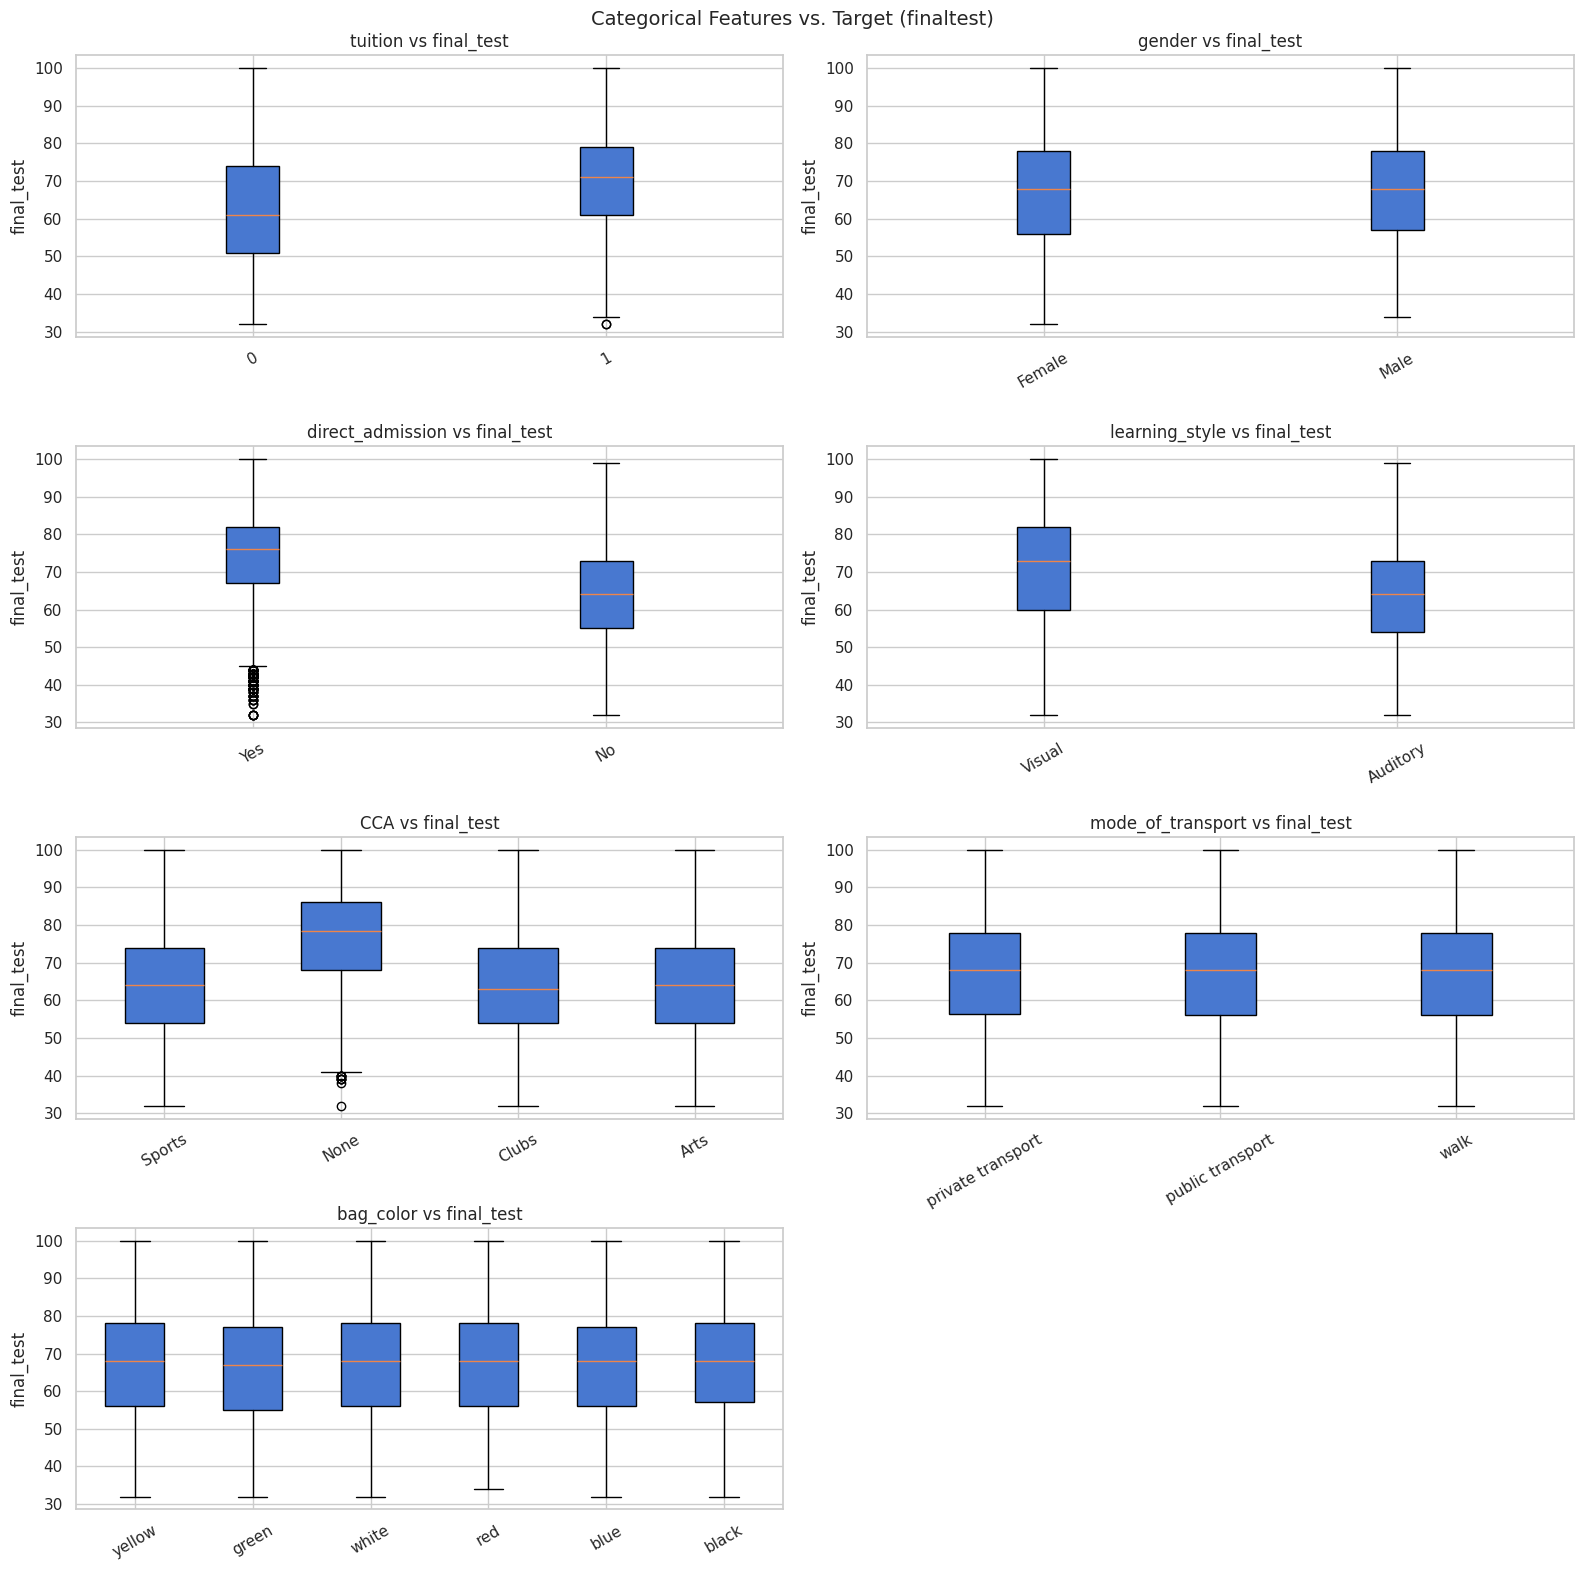


PIPELINE DECISION:
  - Features with near-zero correlation AND no visual separation => candidate for dropping
  - bagcolor: if no meaningful score separation => drop from pipeline
  - Strong separation => high priority, keep and engineer if possible



In [125]:
cat_cols = ['tuition', 'gender', 'direct_admission', 'learning_style',
            'CCA', 'mode_of_transport', 'bag_color']
cat_cols = [c for c in cat_cols if c in df.columns]

n = len(cat_cols)
ncols = 2
nrows = (n + 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    unique_cats = [c for c in df[col].unique() if pd.notna(c)]
    groups = [df.loc[df[col] == cat, 'final_test'].dropna() for cat in unique_cats]
    axes[i].boxplot(groups, labels=[str(c) for c in unique_cats], patch_artist=True)
    axes[i].set_title(f'{col} vs final_test')
    axes[i].set_ylabel('final_test')
    axes[i].tick_params(axis='x', rotation=30)

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Features vs. Target (finaltest)', fontsize=14)
plt.tight_layout()
plt.show()

print("""
PIPELINE DECISION:
  - Features with near-zero correlation AND no visual separation => candidate for dropping
  - bagcolor: if no meaningful score separation => drop from pipeline
  - Strong separation => high priority, keep and engineer if possible
""")


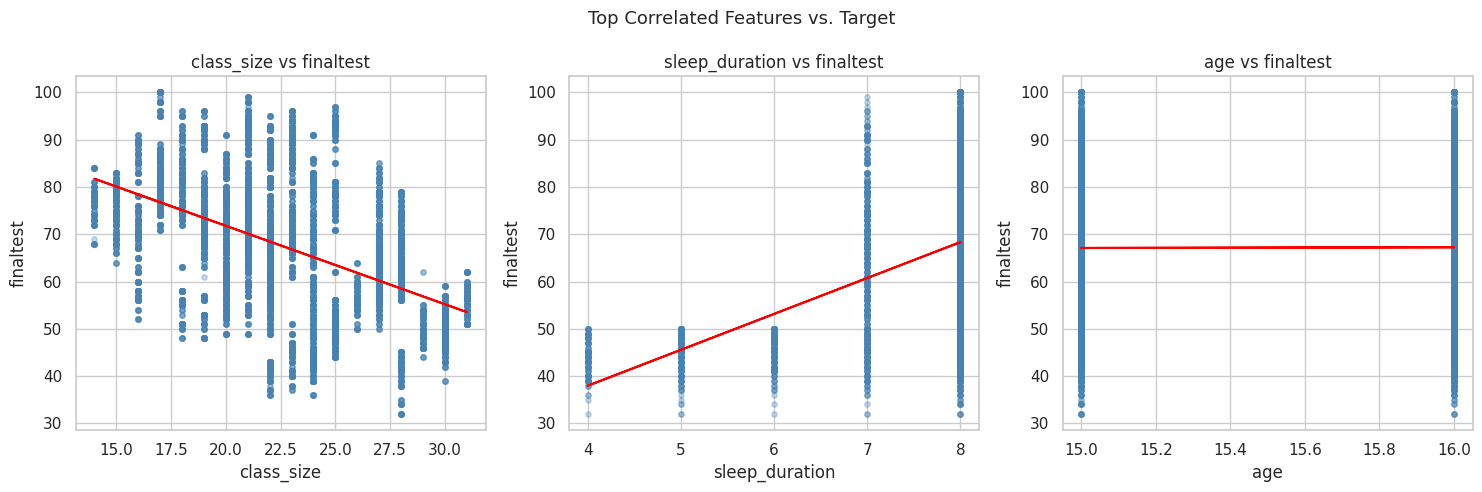

In [126]:
# Scatter plots for top numerical correlates
top_corr = corr_num.abs().nlargest(4).index.tolist()

fig, axes = plt.subplots(1, len(top_corr), figsize=(5 * len(top_corr), 5))
if len(top_corr) == 1:
    axes = [axes]

for ax, col in zip(axes, top_corr):
    mask = df[[col, 'final_test']].dropna()
    ax.scatter(mask[col], mask['final_test'], alpha=0.3, s=15, color='steelblue')
    m, b = np.polyfit(mask[col], mask['final_test'], 1)
    ax.plot(mask[col], m * mask[col] + b, color='red', linewidth=1.5)
    ax.set_xlabel(col)
    ax.set_ylabel('finaltest')
    ax.set_title(f'{col} vs finaltest')

plt.suptitle('Top Correlated Features vs. Target', fontsize=13)
plt.tight_layout()
plt.show()


---
## 9. Multicollinearity Check

**Purpose:** Detect redundant features strongly correlated with each other.
High multicollinearity inflates variance in linear models and leads to unstable coefficients.

**Threshold:** |correlation| > 0.80 between two features signals potential redundancy.


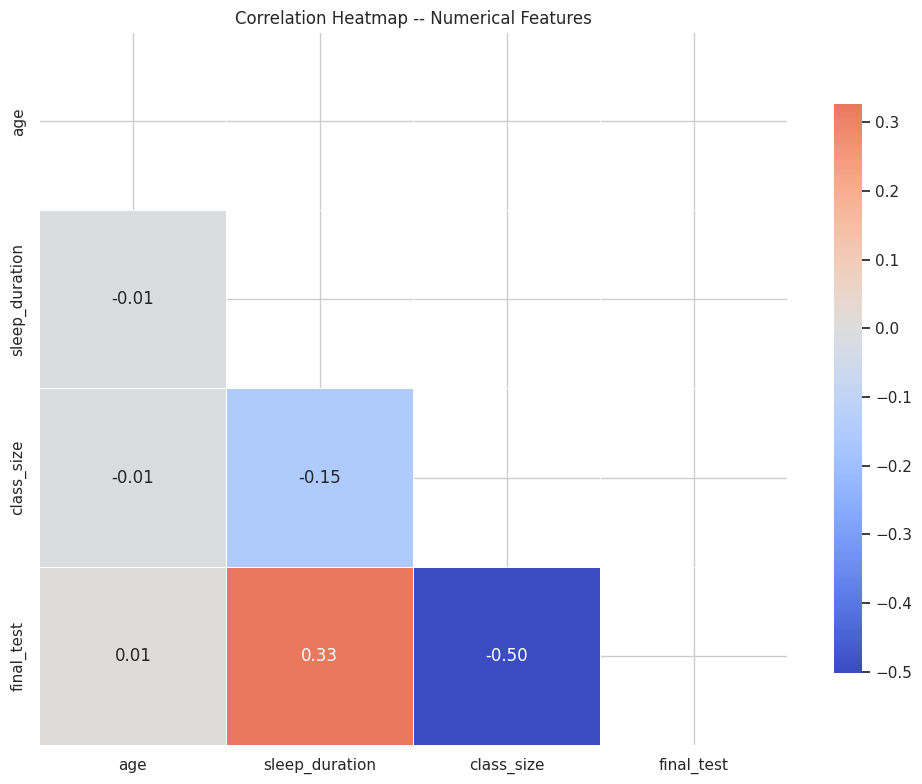

In [127]:
all_num = numerical_cols + ['final_test']
corr_matrix = df[all_num].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap -- Numerical Features')
plt.tight_layout()
plt.show()


In [128]:
high_corr_pairs = []
cols_list = list(corr_matrix.columns)
for i in range(len(cols_list)):
    for j in range(i + 1, len(cols_list)):
        c = corr_matrix.iloc[i, j]
        if abs(c) > 0.80:
            high_corr_pairs.append({
                'Feature A': cols_list[i],
                'Feature B': cols_list[j],
                'Correlation': round(c, 3)
            })

if high_corr_pairs:
    print("=== High Correlation Pairs (|r| > 0.80) ===")
    print(pd.DataFrame(high_corr_pairs).to_string(index=False))
else:
    print("No highly correlated feature pairs found at |r| > 0.80 threshold.")

print("""
PIPELINE DECISION:
  - For each high-corr pair: keep the feature with higher correlation to finaltest
  - Linear models (Ridge/Lasso): regularisation handles multicollinearity
  - Tree-based models: multicollinearity is less of a concern
""")


No highly correlated feature pairs found at |r| > 0.80 threshold.

PIPELINE DECISION:
  - For each high-corr pair: keep the feature with higher correlation to finaltest
  - Linear models (Ridge/Lasso): regularisation handles multicollinearity
  - Tree-based models: multicollinearity is less of a concern



---
## 10. Outlier Analysis

**Purpose:** Identify extreme values that may distort model training.
The treatment strategy (remove, cap, or tolerate) must be consistently applied in the pipeline.

**Method:** IQR-based detection -- values below Q1 - 1.5*IQR or above Q3 + 1.5*IQR.


In [129]:
def iqr_outlier_summary(df, cols):
    rows = []
    for col in cols:
        data = df[col].dropna()
        Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        n_out = ((data < lower) | (data > upper)).sum()
        rows.append({
            'Feature': col, 'Q1': round(Q1, 2), 'Q3': round(Q3, 2), 'IQR': round(IQR, 2),
            'Lower Bound': round(lower, 2), 'Upper Bound': round(upper, 2),
            'Outlier Count': n_out,
            'Outlier %': round(n_out / len(data) * 100, 2)
        })
    return pd.DataFrame(rows)

outlier_df = iqr_outlier_summary(df, numerical_cols)
print(outlier_df.to_string(index=False))


       Feature    Q1    Q3  IQR  Lower Bound  Upper Bound  Outlier Count  Outlier %
           age 15.00 16.00 1.00        13.50        17.50              0       0.00
sleep_duration  8.00  8.00 0.00         8.00         8.00           1229       8.05
    class_size 20.00 27.00 7.00         9.50        37.50              0       0.00


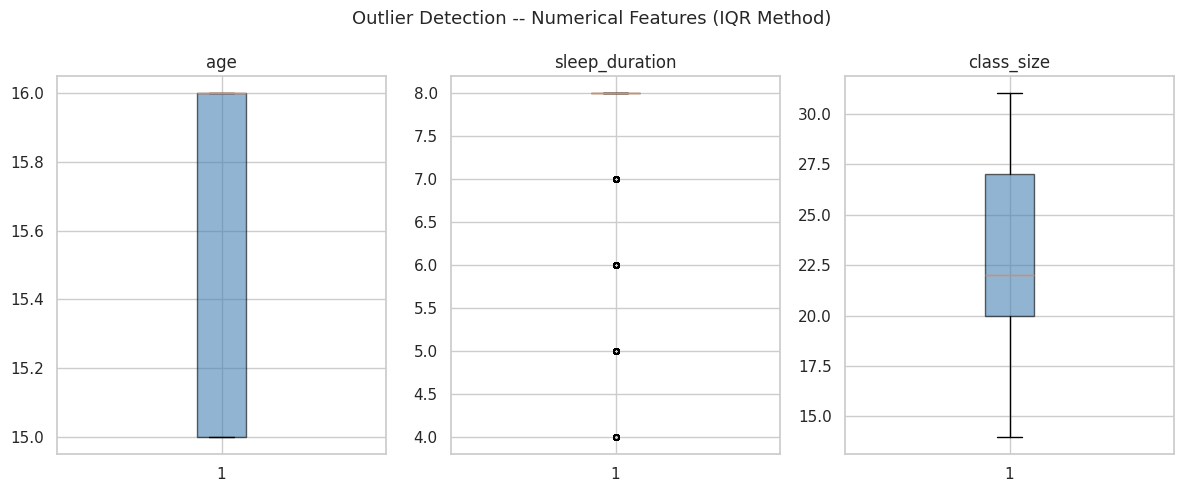


PIPELINE DECISION:
  - Outlier % < 1%  => safe to cap (Winsorizer at 1st/99th percentile)
  - Outlier % > 5%  => use RobustScaler; keep outliers for tree-based models
  - Implement capping as an optional, configurable pipeline step



In [130]:
fig, axes = plt.subplots(1, len(numerical_cols), figsize=(4 * len(numerical_cols), 5))
if len(numerical_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, numerical_cols):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               flierprops=dict(marker='o', color='red', markersize=4))
    ax.set_title(col)

plt.suptitle('Outlier Detection -- Numerical Features (IQR Method)', fontsize=13)
plt.tight_layout()
plt.show()

print("""
PIPELINE DECISION:
  - Outlier % < 1%  => safe to cap (Winsorizer at 1st/99th percentile)
  - Outlier % > 5%  => use RobustScaler; keep outliers for tree-based models
  - Implement capping as an optional, configurable pipeline step
""")


---
## 11. Score Segmentation & Business Context

**Purpose:** Relate the regression output to the business goal -- identifying *weaker students*.
Understanding score bands helps justify evaluation metrics and train/test split strategy.


In [136]:
bins   = [0, 50, 60, 70, 80, 100]
labels = ['Fail', 'C', 'B', 'A2', 'A1']

df['score_band'] = pd.cut(df['final_test'], bins=bins, labels=labels, include_lowest=True)

band_counts = df['score_band'].value_counts().sort_index()
print("=== Score Band Distribution ===")
print(band_counts)


=== Score Band Distribution ===
score_band
Fail    2072
C       3231
B       3513
A2      3752
A1      2694
Name: count, dtype: int64


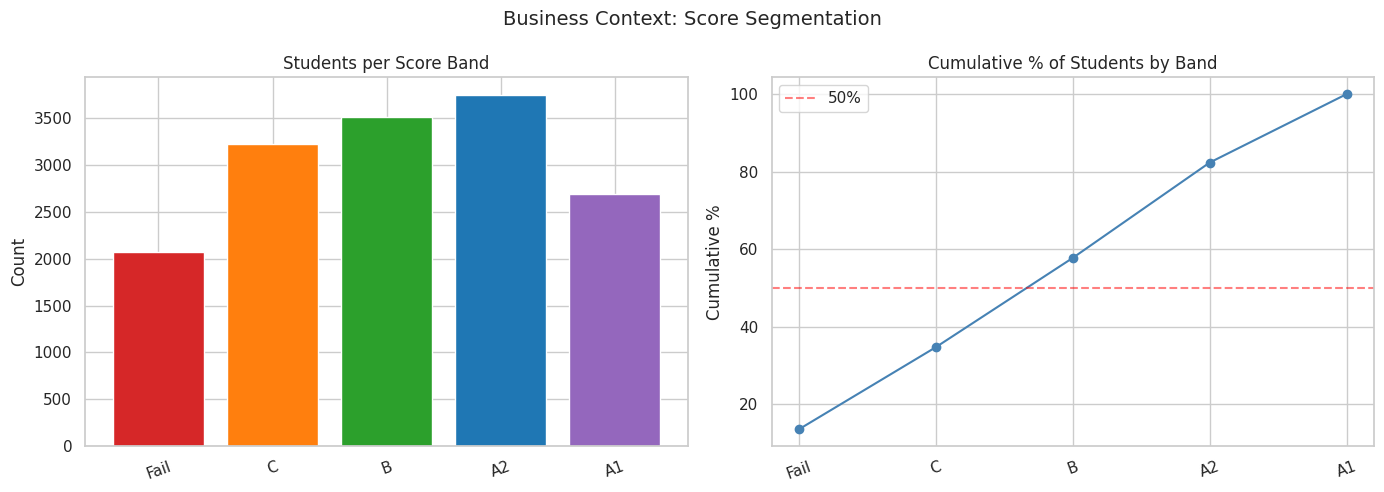


PIPELINE DECISION:
  - Underrepresented low bands => use stratified train/test split
  - Primary metrics: RMSE, MAE (regression)
  - Secondary: R-squared for overall model fit
  - Report errors broken down by score band to assess performance on weak students



In [137]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

band_colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd']
axes[0].bar(band_counts.index.astype(str), band_counts.values,
            color=band_colors, edgecolor='white')
axes[0].set_title('Students per Score Band')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)

cum_pct = (band_counts / band_counts.sum()).cumsum() * 100
axes[1].plot(cum_pct.index.astype(str), cum_pct.values, marker='o', color='steelblue')
axes[1].axhline(50, color='red', linestyle='--', alpha=0.5, label='50%')
axes[1].set_title('Cumulative % of Students by Band')
axes[1].set_ylabel('Cumulative %')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend()

plt.suptitle('Business Context: Score Segmentation', fontsize=14)
plt.tight_layout()
plt.show()

print("""
PIPELINE DECISION:
  - Underrepresented low bands => use stratified train/test split
  - Primary metrics: RMSE, MAE (regression)
  - Secondary: R-squared for overall model fit
  - Report errors broken down by score band to assess performance on weak students
""")


---
## 12. EDA Summary & Pipeline Decisions

This section consolidates all findings into a concise reference for the `README.md`.


In [133]:
proc_data = [
    ('studentid',        'Drop -- ID column, no predictive value'),
    ('age',              'Keep -- Numerical; StandardScaler'),
    ('hoursperweek',     'Keep -- Numerical; log1p if skewed, then StandardScaler'),
    ('attendancerate',   'Keep -- Numerical; StandardScaler'),
    ('numberofsiblings', 'Keep -- Discrete numerical; StandardScaler'),
    ('nmale',            'Engineer => class_size, male_ratio; then drop'),
    ('nfemale',          'Engineer => class_size, male_ratio; then drop'),
    ('sleeptime',        'Engineer => sleep_duration (hours); then drop'),
    ('waketime',         'Engineer => sleep_duration (hours); then drop'),
    ('tuition',          'Keep -- Binary categorical; LabelEncoder or OHE'),
    ('gender',           'Keep -- Binary categorical; LabelEncoder or OHE'),
    ('directadmission',  'Keep -- Nominal categorical; OneHotEncoder'),
    ('CCA',              'Keep -- Nominal categorical; OneHotEncoder'),
    ('learningstyle',    'Keep -- Nominal categorical; OneHotEncoder'),
    ('modeoftransport',  'Keep -- Nominal categorical; OneHotEncoder'),
    ('bagcolor',         'Review -- Drop if no target correlation, else OneHotEncoder'),
]

proc_df = pd.DataFrame(proc_data, columns=['Feature', 'Pipeline Treatment'])
print(proc_df.to_string(index=False))


         Feature                                          Pipeline Treatment
       studentid                      Drop -- ID column, no predictive value
             age                           Keep -- Numerical; StandardScaler
    hoursperweek     Keep -- Numerical; log1p if skewed, then StandardScaler
  attendancerate                           Keep -- Numerical; StandardScaler
numberofsiblings                  Keep -- Discrete numerical; StandardScaler
           nmale               Engineer => class_size, male_ratio; then drop
         nfemale               Engineer => class_size, male_ratio; then drop
       sleeptime               Engineer => sleep_duration (hours); then drop
        waketime               Engineer => sleep_duration (hours); then drop
         tuition             Keep -- Binary categorical; LabelEncoder or OHE
          gender             Keep -- Binary categorical; LabelEncoder or OHE
 directadmission                  Keep -- Nominal categorical; OneHotEncoder

### Recommended Models (minimum 3 required)

| # | Model | Rationale from EDA |
|---|---|---|
| 1 | **Ridge Regression** | Baseline linear model; handles multicollinearity via L2 regularisation |
| 2 | **Random Forest Regressor** | Robust to outliers; captures non-linear patterns from scatter plots |
| 3 | **Gradient Boosting (XGBoost / LightGBM)** | Strong performance on mixed-type tabular data |
| (opt) | **ElasticNet** | Use if multicollinearity is high; L1+L2 penalty |

### Evaluation Metrics

| Metric | Rationale |
|---|---|
| **RMSE** | Penalises large prediction errors -- critical for identifying very weak students |
| **MAE** | Robust to outliers; directly interpretable in score units |
| **R-squared** | Measures proportion of variance explained by the model |

### Train/Test Split Strategy
- Use **stratified split** based on score bands if distribution is imbalanced
- Recommended split: **80% train / 20% test** with fixed `random_state`
- Use **5-fold cross-validation** on training set for model selection and hyperparameter tuning
